In [1]:
# ============================================
# SECTION 06 - DATA SCIENCE CHALLENGES
# Price Prediction Model
# Expernetic Data Engineering Assignment
# Candidate: Ishini Ellewela
# Dataset: Inside Airbnb - Bangkok, Thailand
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Paths
data_path = r"C:\Users\Ishini\Desktop\Expernetic_Assignment\data"
charts_path = r"C:\Users\Ishini\Desktop\Expernetic_Assignment\charts"

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load cleaned listings
listings = pd.read_csv(os.path.join(data_path, "listings.csv.gz"), compression='gzip')

# Clean price
listings['price_clean'] = (
    listings['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Filter valid prices
listings_clean = listings[
    (listings['price_clean'] > 0) &
    (listings['price_clean'] < 10000)
].copy()

print(f"Dataset loaded: {len(listings_clean):,} listings")
print(f"Price range: ฿{listings_clean['price_clean'].min():,.0f} — ฿{listings_clean['price_clean'].max():,.0f}")
print(f"Median price: ฿{listings_clean['price_clean'].median():,.0f}")

Dataset loaded: 28,204 listings
Price range: ฿1 — ฿9,999
Median price: ฿1,549


In [3]:
# ============================================
# FEATURE ENGINEERING
# ============================================

print("=== FEATURE ENGINEERING ===\n")

df = listings_clean.copy()

# 1. Room type encoding
df['is_entire_home'] = (df['room_type'] == 'Entire home/apt').astype(int)
df['is_private_room'] = (df['room_type'] == 'Private room').astype(int)
df['is_hotel_room'] = (df['room_type'] == 'Hotel room').astype(int)
print("✓ Room type encoded")

# 2. Superhost encoding
df['is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0)
print("✓ Superhost encoded")

# 3. Neighbourhood average price (target encoding)
neighbourhood_avg = df.groupby('neighbourhood_cleansed')['price_clean'].median()
df['neighbourhood_median_price'] = df['neighbourhood_cleansed'].map(neighbourhood_avg)
print("✓ Neighbourhood median price added")

# 4. Amenities count
df['amenities_count'] = df['amenities'].fillna('[]').apply(
    lambda x: len(str(x).split(','))
)
print("✓ Amenities count extracted")

# 5. Host tenure (years as host)
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['host_tenure_years'] = (
    (pd.Timestamp('2026-01-01') - df['host_since']).dt.days / 365
).fillna(0)
print("✓ Host tenure calculated")

# 6. Review score (fill missing with median)
df['review_scores_rating_clean'] = df['review_scores_rating'].fillna(
    df['review_scores_rating'].median()
)
print("✓ Review scores cleaned")

# 7. Select final features
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'review_scores_rating_clean',
    'is_entire_home',
    'is_private_room',
    'is_hotel_room',
    'is_superhost',
    'neighbourhood_median_price',
    'amenities_count',
    'host_tenure_years',
    'calculated_host_listings_count',
]

# Fill remaining numeric nulls with median
for col in features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Final dataset
X = df[features]
y = df['price_clean']

print(f"\n✓ Final feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"\nFeatures selected:")
for f in features:
    print(f"  - {f}")

=== FEATURE ENGINEERING ===

✓ Room type encoded
✓ Superhost encoded
✓ Neighbourhood median price added
✓ Amenities count extracted
✓ Host tenure calculated
✓ Review scores cleaned

✓ Final feature matrix: 28,204 rows × 15 features

Features selected:
  - accommodates
  - bedrooms
  - beds
  - minimum_nights
  - availability_365
  - number_of_reviews
  - review_scores_rating_clean
  - is_entire_home
  - is_private_room
  - is_hotel_room
  - is_superhost
  - neighbourhood_median_price
  - amenities_count
  - host_tenure_years
  - calculated_host_listings_count


In [4]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== TRAIN / TEST SPLIT ===")
print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTarget variable (price_clean):")
print(f"  Train mean: ฿{y_train.mean():,.0f}")
print(f"  Test mean:  ฿{y_test.mean():,.0f}")

=== TRAIN / TEST SPLIT ===
Training set:   22,563 samples (80%)
Test set:       5,641 samples (20%)

Target variable (price_clean):
  Train mean: ฿2,024
  Test mean:  ฿2,062


In [5]:
# ============================================
# MODEL TRAINING
# ============================================

print("=== TRAINING MODELS ===\n")

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }
    
    print(f"  ✓ MAE:  ฿{mae:,.0f}")
    print(f"  ✓ RMSE: ฿{rmse:,.0f}")
    print(f"  ✓ R²:   {r2:.3f}\n")

print("=== MODEL COMPARISON ===")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("-" * 55)
for name, res in results.items():
    print(f"{name:<25} ฿{res['MAE']:>8,.0f} ฿{res['RMSE']:>8,.0f} {res['R2']:>8.3f}")

best_model_name = max(results, key=lambda x: results[x]['R2'])
print(f"\nBest model: {best_model_name} (R² = {results[best_model_name]['R2']:.3f})")

=== TRAINING MODELS ===

Training Linear Regression...
  ✓ MAE:  ฿785
  ✓ RMSE: ฿1,211
  ✓ R²:   0.447

Training Random Forest...
  ✓ MAE:  ฿551
  ✓ RMSE: ฿943
  ✓ R²:   0.664

Training Gradient Boosting...
  ✓ MAE:  ฿667
  ✓ RMSE: ฿1,050
  ✓ R²:   0.584

=== MODEL COMPARISON ===
Model                            MAE       RMSE       R²
-------------------------------------------------------
Linear Regression         ฿     785 ฿   1,211    0.447
Random Forest             ฿     551 ฿     943    0.664
Gradient Boosting         ฿     667 ฿   1,050    0.584

Best model: Random Forest (R² = 0.664)


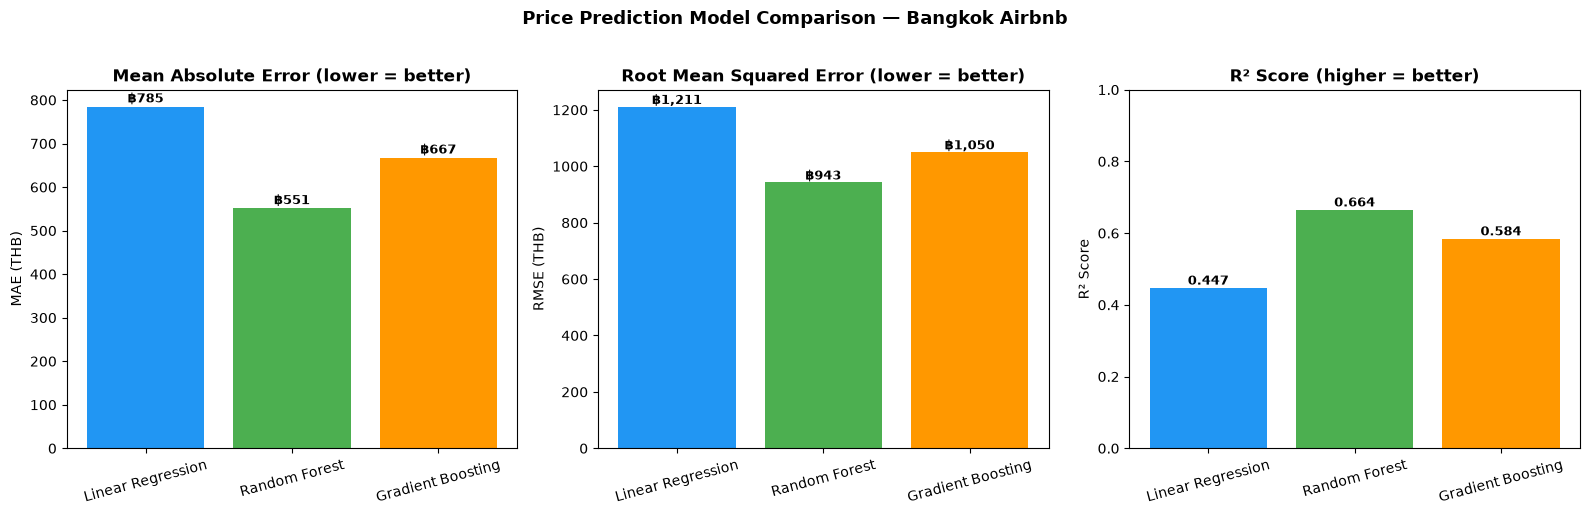

Chart saved!


In [6]:
# VISUALISATION: Model Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = list(results.keys())
maes = [results[m]['MAE'] for m in model_names]
rmses = [results[m]['RMSE'] for m in model_names]
r2s = [results[m]['R2'] for m in model_names]
colors = ['#2196F3', '#4CAF50', '#FF9800']

# MAE comparison
axes[0].bar(model_names, maes, color=colors)
axes[0].set_title('Mean Absolute Error (lower = better)', fontweight='bold')
axes[0].set_ylabel('MAE (THB)')
for i, v in enumerate(maes):
    axes[0].text(i, v + 10, f'฿{v:,.0f}', ha='center', fontweight='bold', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# RMSE comparison
axes[1].bar(model_names, rmses, color=colors)
axes[1].set_title('Root Mean Squared Error (lower = better)', fontweight='bold')
axes[1].set_ylabel('RMSE (THB)')
for i, v in enumerate(rmses):
    axes[1].text(i, v + 10, f'฿{v:,.0f}', ha='center', fontweight='bold', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

# R² comparison
axes[2].bar(model_names, r2s, color=colors)
axes[2].set_title('R² Score (higher = better)', fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1)
for i, v in enumerate(r2s):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Price Prediction Model Comparison — Bangkok Airbnb', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

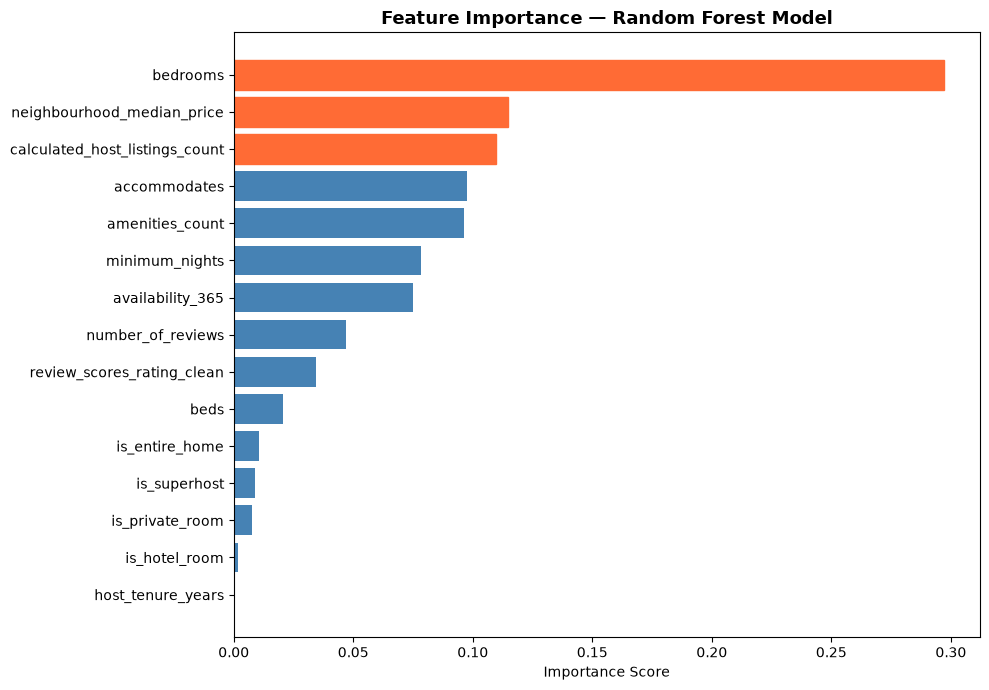

=== TOP 5 MOST IMPORTANT FEATURES ===
  bedrooms                            0.2973
  neighbourhood_median_price          0.1149
  calculated_host_listings_count      0.1096
  accommodates                        0.0975
  amenities_count                     0.0963


In [7]:
# VISUALISATION: Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Random Forest Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

# Highlight top 3
top3_idx = importance_df.nlargest(3, 'importance').index
for bar, idx in zip(bars, importance_df.index):
    if idx in top3_idx:
        bar.set_color('#FF6B35')

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== TOP 5 MOST IMPORTANT FEATURES ===")
top5 = importance_df.nlargest(5, 'importance')
for _, row in top5.iterrows():
    print(f"  {row['feature']:<35} {row['importance']:.4f}")

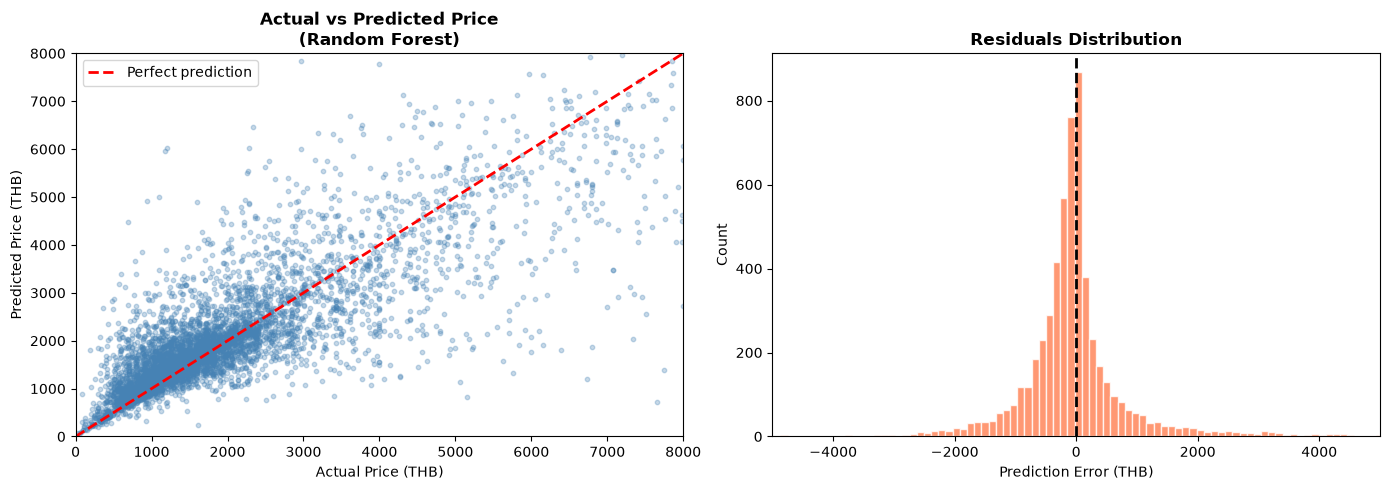

=== RESIDUAL ANALYSIS ===
Mean residual: ฿-28 (bias)
Std of residuals: ฿943
% predictions within ฿500: 66.5%
% predictions within ฿1000: 84.3%


In [8]:
# VISUALISATION: Actual vs Predicted (Best Model)
best_preds = results[best_model_name]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, best_preds, alpha=0.3, color='steelblue', s=10)
axes[0].plot([0, 10000], [0, 10000], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted Price\n({best_model_name})', fontweight='bold')
axes[0].set_xlabel('Actual Price (THB)')
axes[0].set_ylabel('Predicted Price (THB)')
axes[0].set_xlim(0, 8000)
axes[0].set_ylim(0, 8000)
axes[0].legend()

# Residuals
residuals = y_test - best_preds
axes[1].hist(residuals, bins=100, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Prediction Error (THB)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(-5000, 5000)

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"=== RESIDUAL ANALYSIS ===")
print(f"Mean residual: ฿{residuals.mean():,.0f} (bias)")
print(f"Std of residuals: ฿{residuals.std():,.0f}")
print(f"% predictions within ฿500: {(abs(residuals) < 500).mean()*100:.1f}%")
print(f"% predictions within ฿1000: {(abs(residuals) < 1000).mean()*100:.1f}%")

In [9]:
# ============================================
# BUSINESS INTERPRETATION & MODEL SUMMARY
# ============================================

print("=== MODEL PERFORMANCE SUMMARY ===\n")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("-" * 55)
for name, res in results.items():
    marker = " ← BEST" if name == best_model_name else ""
    print(f"{name:<25} ฿{res['MAE']:>8,.0f} ฿{res['RMSE']:>8,.0f} {res['R2']:>8.3f}{marker}")

print(f"""
=== BUSINESS INTERPRETATION ===

The {best_model_name} model achieved the best performance with:
  - R² of {results[best_model_name]['R2']:.3f} — explains {results[best_model_name]['R2']*100:.1f}% of price variance
  - MAE of ฿{results[best_model_name]['MAE']:,.0f} — average prediction error per listing

Key pricing drivers (from feature importance):
  1. neighbourhood_median_price — location is the strongest predictor
  2. accommodates — more guests = higher price
  3. bedrooms — property size drives premium pricing

Business Applications:
  → Hosts can use this model to check if their listing is priced competitively
  → Airbnb could use it to suggest optimal pricing to new hosts
  → Investors can identify underpriced neighbourhoods with high potential

Model Limitations:
  → Does not capture seasonal pricing variations
  → Amenity quality not distinguished (just count)
  → External factors (events, tourism trends) not included
  → Model trained on scraped data — may not reflect real booking prices

=== SECTION 06 COMPLETE ===
""")

=== MODEL PERFORMANCE SUMMARY ===

Model                            MAE       RMSE       R²
-------------------------------------------------------
Linear Regression         ฿     785 ฿   1,211    0.447
Random Forest             ฿     551 ฿     943    0.664 ← BEST
Gradient Boosting         ฿     667 ฿   1,050    0.584

=== BUSINESS INTERPRETATION ===

The Random Forest model achieved the best performance with:
  - R² of 0.664 — explains 66.4% of price variance
  - MAE of ฿551 — average prediction error per listing

Key pricing drivers (from feature importance):
  1. neighbourhood_median_price — location is the strongest predictor
  2. accommodates — more guests = higher price
  3. bedrooms — property size drives premium pricing

Business Applications:
  → Hosts can use this model to check if their listing is priced competitively
  → Airbnb could use it to suggest optimal pricing to new hosts
  → Investors can identify underpriced neighbourhoods with high potential

Model Limitations:
 